# Random Forest Classifier

In this notebook I use a Random Forest classifier to predict whether Player 1 wins a tennis match.

The model is trained on the same training set used for the ANN and evaluated on the 2023 validation set.

Different Random Forest configurations are tested in order to fine-tune the model parameters.

In [2]:
from pathlib import Path 

import numpy as np 
import pandas as pd 

import matplotlib.pyplot as plt 
import seaborn as sns 

import sys
from pathlib import Path
PROJECT_ROOT = Path("..").resolve()
if str(PROJECT_ROOT) not in sys.path:
    sys.path.append(str(PROJECT_ROOT))
    
from src.preprocessing import (
    fit_preprocessor,
    transform_data,
    categorical_features,
    numeric_features
)

from src.temporal_cv import(
    validation_years,
    create_temporal_folds
)

from src.evaluation import (
    evaluate_model
)

from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    confusion_matrix, 
    classification_report
)

In [3]:
PROCESSED_DATA_DIR = Path("../data/processed")

input_file = ( PROCESSED_DATA_DIR / "feature_split_matches.csv")

matches = pd.read_csv(
    input_file, parse_dates=["Date"]
)

matches = matches.sort_values(
    by=["Date", "MatchID"]
).reset_index(drop=True)

print("Dataset shape:", matches.shape)

print(matches["DataSplit"].value_counts())

Dataset shape: (26536, 53)
DataSplit
Training      18810
Test           5119
Validation     2607
Name: count, dtype: int64


In [4]:
train_data = matches.loc[
    matches["DataSplit"] == "Training"
].copy()

validation_data = matches.loc[
    matches["DataSplit"] == "Validation"
].copy()

test_data = matches.loc[
    matches["DataSplit"] == "Test"
].copy()

print( 
    "Training:", 
    train_data["Date"].min(), 
    "-", 
    train_data["Date"].max()
)

print(
    "Validation:", 
    validation_data["Date"].min(),
    "-", 
    validation_data["Date"].max()
)

print(
    "Test:", 
    test_data["Date"].min(), 
    "-", 
    test_data["Date"].max()
)

Training: 2015-01-05 00:00:00 - 2022-11-20 00:00:00
Validation: 2023-01-01 00:00:00 - 2023-12-31 00:00:00
Test: 2024-01-01 00:00:00 - 2025-11-16 00:00:00


In [5]:
print(
    "Numerical features:",
    len(numeric_features)
)

print(
    "Categorical features:",
    len(categorical_features)
)

print(
    "Raw selected features:",
    len(numeric_features)
    + len(categorical_features)
)

Numerical features: 30
Categorical features: 5
Raw selected features: 35


Create the temporal cross-validation folds

In [6]:

# inside the 2015-2022 development training period.

temporal_folds = create_temporal_folds(
    train_data,
    validation_years
)

print(
    "Number of temporal folds:",
    len(temporal_folds)
)

pd.DataFrame(temporal_folds)

Number of temporal folds: 4


,Fold,TrainingMatches,ValidationMatches,TrainingStartYear,TrainingEndYear,ValidationYear
0,1,10135,2497,2015,2018,2019
1,2,12632,1231,2015,2019,2020
2,3,13863,2402,2015,2020,2021
3,4,16265,2545,2015,2021,2022


In [7]:
(
    numeric_medians,
    categorical_modes,
    one_hot_encoder
) = fit_preprocessor(
    train_data
)

X_train = transform_data(
    train_data,
    numeric_medians,
    categorical_modes,
    one_hot_encoder
)

X_validation = transform_data(
    validation_data,
    numeric_medians,
    categorical_modes,
    one_hot_encoder
)

y_train = train_data["Player1Won"].to_numpy()
y_validation = validation_data["Player1Won"].to_numpy()


In [8]:
print("Training X:", X_train.shape)
print("Validation X:", X_validation.shape)
print("Training y:", y_train.shape)
print("Validation y:", y_validation.shape)

assert X_train.shape[1] == 50
assert X_validation.shape[1] == 50

assert X_train.isna().sum().sum() == 0
assert X_validation.isna().sum().sum() == 0

print(
    "Random Forest preprocessing check passed."
)

Training X: (18810, 50)
Validation X: (2607, 50)
Training y: (18810,)
Validation y: (2607,)
Random Forest preprocessing check passed.


Unlike the ANN, I do not standardize the features for the Random Forest.

A Random Forest makes decisions by comparing individual feature values
with thresholds. Therefore, a feature measured on a larger numerical
scale does not automatically dominate the model in the same way it
could in a distance-based model or a neural network.

The one-hot encoded categorical features can therefore remain 0/1,
while the numerical features remain on their original scales.

In [10]:
configurations = [
    {
        "name": "RF 100", 
        "n_estimators": 100, 
        "max_depth": None, 
        "min_samples_leaf": 1
    },
    {
        "name": "RF 200", 
        "n_estimators": 200, 
        "max_depth": None, 
        "min_samples_leaf": 1
    },
    {
        "name": "RF 200 depth 10", 
        "n_estimators": 200, 
        "max_depth": 10, 
        "min_samples_leaf": 1
    },
    {
        "name": "RF 200 depth 15", 
        "n_estimators": 200, 
        "max_depth": 15, 
        "min_samples_leaf": 1
    },
    {
        "name": "RF 300 depth 10 leaf 2", 
        "n_estimators": 300, 
        "max_depth": 10, 
        "min_samples_leaf": 2
    },
    {
        "name": "RF 300 depth 15 leaf 2", 
        "n_estimators": 300, 
        "max_depth": 15, 
        "min_samples_leaf": 2
    }
]

RANDOM FOREST CROSS VALIDATION

In [11]:
# One row will be stored for every:
# Random Forest configuration × temporal fold
# 6 configurations × 4 folds = 24 experiments.

rf_cv_results = []


# Test every Random Forest configuration.
for configuration in configurations:

    print("Testing Random Forest:", configuration["name"] )

    # Evaluate the current configuration on all four temporal folds.
    for fold in temporal_folds:

        fold_number = fold["Fold"]
        validation_year = fold["ValidationYear"]


        print(
            "Fold",
            fold_number,
            "- validation year:",
            validation_year
        )

        # Training contains all matches before the current validation year.

        fold_train = train_data.loc[
            train_data["Date"].dt.year
            < validation_year
        ].copy()

        # Validation contains only matches fromthe current validation year.
        fold_validation = train_data.loc[
            train_data["Date"].dt.year
            == validation_year
        ].copy()

        # Every temporal fold gets its own preprocessing.
        # This prevents future information from entering an earlier validation year.
        (
            fold_numeric_medians,
            fold_categorical_modes,
            fold_encoder
        ) = fit_preprocessor(
            fold_train
        )

        #transform

        X_fold_train = transform_data(
            fold_train,
            fold_numeric_medians,
            fold_categorical_modes,
            fold_encoder
        )


        X_fold_validation = transform_data(
            fold_validation,
            fold_numeric_medians,
            fold_categorical_modes,
            fold_encoder
        )


        # Targets.

        y_fold_train = (
            fold_train[
                "Player1Won"
            ].to_numpy()
        )

        y_fold_validation = (
            fold_validation[
                "Player1Won"
            ].to_numpy()
        )

        #build forest

        current_model = RandomForestClassifier(
            n_estimators=configuration["n_estimators"],
            max_depth=configuration["max_depth"],
            min_samples_leaf=configuration["min_samples_leaf"],
            max_features="sqrt",
            random_state=42,
            # Use all available CPU cores.
            n_jobs=-1
        )


        #train
        current_model.fit( X_fold_train, y_fold_train)


        #predict temporal validation fold
        current_predictions = ( current_model.predict( X_fold_validation))

        # Probability that Player 1 wins.
        current_probabilities = (current_model.predict_proba( X_fold_validation)[:, 1])
        
        #evaluate
        current_fold_results = evaluate_model(
            y_true=y_fold_validation,
            y_pred=current_predictions,
            model_name= configuration["name"],
            y_probability= current_probabilities
        )

        # evaluate_model returns a one-row DataFrame.
        # Convert it into one dictionary.
        current_fold_result = (current_fold_results.iloc[0].to_dict())


        # Add information identifying the fold.

        current_fold_result[
            "Fold"
        ] = fold_number

        current_fold_result[
            "ValidationYear"
        ] = validation_year


        # Store the result.

        rf_cv_results.append(
            current_fold_result
        )


        print(
            "  Accuracy:",
            round(current_fold_result["Accuracy"], 4)
        )

Testing Random Forest: RF 100
Fold 1 - validation year: 2019
  Accuracy: 0.6075
Fold 2 - validation year: 2020
  Accuracy: 0.6263
Fold 3 - validation year: 2021
  Accuracy: 0.637
Fold 4 - validation year: 2022
  Accuracy: 0.6479
Testing Random Forest: RF 200
Fold 1 - validation year: 2019
  Accuracy: 0.6167
Fold 2 - validation year: 2020
  Accuracy: 0.6182
Fold 3 - validation year: 2021
  Accuracy: 0.6253
Fold 4 - validation year: 2022
  Accuracy: 0.6507
Testing Random Forest: RF 200 depth 10
Fold 1 - validation year: 2019
  Accuracy: 0.6268
Fold 2 - validation year: 2020
  Accuracy: 0.6353
Fold 3 - validation year: 2021
  Accuracy: 0.642
Fold 4 - validation year: 2022
  Accuracy: 0.6625
Testing Random Forest: RF 200 depth 15
Fold 1 - validation year: 2019
  Accuracy: 0.6235
Fold 2 - validation year: 2020
  Accuracy: 0.6377
Fold 3 - validation year: 2021
  Accuracy: 0.637
Fold 4 - validation year: 2022
  Accuracy: 0.6597
Testing Random Forest: RF 300 depth 10 leaf 2
Fold 1 - validation

In [12]:
# Convert the 24 fold-level experimentsinto a DataFrame.

rf_cv_fold_results = pd.DataFrame(
    rf_cv_results
)

rf_cv_fold_results

,Model,Accuracy,BalancedAccuracy,Precision,Recall,F1,ROC-AUC,LogLoss,Fold,ValidationYear
0,RF 100,0.607529,0.607245,0.611015,0.573506,0.591667,0.661231,0.647474,1,2019
1,RF 100,0.626320,0.628819,0.665434,0.563380,0.610169,0.690859,0.630528,2,2020
2,RF 100,0.636969,0.635588,0.627149,0.601041,0.613818,0.679149,0.641886,3,2021
3,RF 100,0.647937,0.647722,0.654882,0.615506,0.634584,0.699112,0.629040,4,2022
4,RF 200,0.616740,0.616575,0.617377,0.596931,0.606982,0.669652,0.642385,1,2019
5,RF 200,0.618197,0.619813,0.648506,0.577465,0.610927,0.687425,0.632660,2,2020
6,RF 200,0.625312,0.624346,0.611848,0.600173,0.605954,0.678918,0.641316,3,2021
7,RF 200,0.650688,0.650449,0.659033,0.614715,0.636103,0.704677,0.625113,4,2022
8,RF 200 depth 10,0.626752,0.626483,0.631218,0.594507,0.612313,0.686772,0.633309,1,2019
9,RF 200 depth 10,0.635256,0.637426,0.672101,0.580595,0.623006,0.706179,0.621704,2,2020


In [13]:
print("Number of cv experiments", len(rf_cv_fold_results))

assert len(rf_cv_fold_results) == len(configurations)*len(temporal_folds)

Number of cv experiments 24


In [16]:
rf_cv_summary = rf_cv_fold_results.groupby("Model", as_index=False).agg(
        MeanAccuracy = ("Accuracy", "mean"),
        StdAccuracy = ("Accuracy", "std"),
        MeanBalancedAccuracy = ("BalancedAccuracy", "mean"),
        MeanF1Score = ("F1", "mean"),
        MeanROC_AUC = ("ROC-AUC", "mean"),
        MeanLogLoss = ("LogLoss", "mean")
)

In [17]:
#prefer configuration with highest avarage temporal-CV accuracy
#ROC-AUC used as tie-breaker
rf_cv_summary = rf_cv_summary.sort_values(
    by=["MeanAccuracy", "MeanROC_AUC"],
    ascending=[False, False]
).reset_index(drop=True)

rf_cv_summary

,Model,MeanAccuracy,StdAccuracy,MeanBalancedAccuracy,MeanF1Score,MeanROC_AUC,MeanLogLoss
0,RF 200 depth 10,0.641612,0.015238,0.641649,0.623721,0.702230,0.624893
1,RF 200 depth 15,0.639484,0.014980,0.639569,0.625950,0.694884,0.629909
2,RF 300 depth 10 leaf 2,0.639258,0.011782,0.639344,0.622160,0.703647,0.623535
3,RF 300 depth 15 leaf 2,0.638168,0.013094,0.638338,0.623833,0.697278,0.628350
4,RF 100,0.629689,0.017209,0.629844,0.612559,0.682588,0.637232
5,RF 200,0.627734,0.015754,0.627796,0.614992,0.685168,0.635369


In [18]:
best_model_name = (rf_cv_summary.iloc[0]["Model"])
print("Selected Random Forest:", best_model_name)

Selected Random Forest: RF 200 depth 10


In [19]:
#store and print the complete parameter dictionary of the best model

best_configuration = next(
    configuration
    for configuration in configurations 
    if configuration["name"]== best_model_name
)

best_configuration

{'name': 'RF 200 depth 10',
 'n_estimators': 200,
 'max_depth': 10,
 'min_samples_leaf': 1}

CREATE NEW RF

In [20]:
best_model = RandomForestClassifier(
    n_estimators=best_configuration["n_estimators"],
    max_depth=best_configuration["max_depth"],
    min_samples_leaf=best_configuration["min_samples_leaf"],
    max_features="sqrt",
    random_state=42,
    n_jobs=-1
)

In [21]:
# Train the selected configuration using the complete 2015-2022 model-development training period.

best_model.fit(
    X_train,
    y_train
)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",200
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",10
,"n_jobs n_jobs: int, default=NoneThe number of jobs to run in parallel. :meth:`fit`, :meth:`predict`,:meth:`decision_path` and :meth:`apply` are all parallelized over thetrees. ``None`` means 1 unless in a :obj:`joblib.parallel_backend`context. ``-1`` means using all processors. See :term:`Glossary<n_jobs>` for more details.",-1
,"random_state random_state: int, RandomState instance or None, default=NoneControls both the randomness of the bootstrapping of the samples usedwhen building trees (if ``bootstrap=True``) and the sampling of thefeatures to consider when looking for the best split at each node(if ``max_features < n_features``).See :term:`Glossary <random_state>` for details.",42
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total n

In [22]:
best_validation_predictions = (
    best_model.predict(X_validation)
)

best_validation_probabilities = (
    best_model.predict_proba(X_validation)[:, 1]
)

print(
    classification_report(
        y_validation, 
        best_validation_predictions, 
        target_names=[
            "Player 2 wins", 
            "Player 1 wins"
        ], 
        zero_division=0
    )
)

               precision    recall  f1-score   support

Player 2 wins       0.66      0.64      0.65      1368
Player 1 wins       0.62      0.64      0.63      1239

     accuracy                           0.64      2607
    macro avg       0.64      0.64      0.64      2607
 weighted avg       0.64      0.64      0.64      2607



In [23]:
best_rf_result= evaluate_model(
    y_true=y_validation,
    y_pred=best_validation_predictions,
    model_name=best_model_name,
    y_probability=best_validation_probabilities
)

best_rf_result

,Model,Accuracy,BalancedAccuracy,Precision,Recall,F1,ROC-AUC,LogLoss
0,RF 200 depth 10,0.64135,0.641174,0.619122,0.637611,0.628231,0.703815,0.624294


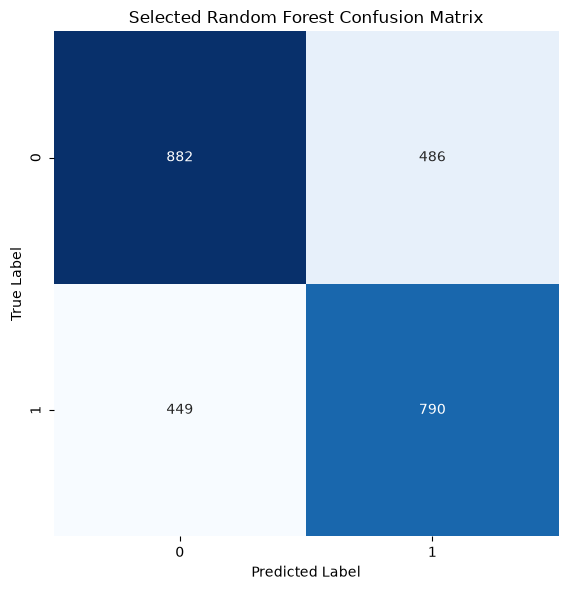

In [24]:
matrix = confusion_matrix(
    y_validation, 
    best_validation_predictions
)

fig, axes = plt.subplots(
    figsize=(6, 6), 
    tight_layout=True
)

sns.heatmap(
    matrix, 
    square=True, 
    annot=True, 
    fmt="d", 
    cbar=False, 
    cmap="Blues"
)

axes.set_xlabel("Predicted Label")
axes.set_ylabel("True Label")
axes.set_title("Selected Random Forest Confusion Matrix")
plt.show()

In [26]:
# Random Forest assigns an importance value
# to every input feature used by the model.
#
# X_train.columns contains the exact 50 input feature names,
# including both:
#
# - numerical features
# - one-hot encoded categorical features

feature_importance = pd.DataFrame(
    {
        "Feature": X_train.columns,
        "Importance": best_model.feature_importances_ #assigns an importance value to each input feature.
        #The values add approximately to 1
    }
)

# Order the features from most important to least important.
feature_importance = (
    feature_importance.sort_values(
        by="Importance", ascending=False
    ).reset_index(drop=True)
)
feature_importance

,Feature,Importance
0,PointsDifference,0.125788
1,RankDifference,0.097723
2,WinRateDifference,0.081795
3,SurfaceWinRateDifference,0.063267
4,Player2Points,0.047606
5,Player1Points,0.046803
6,Player1Rank,0.043834
7,Player2Rank,0.041618
8,SurfaceMatchesDifference,0.038916
9,ExperienceDifference,0.036477


In [27]:
print("Number of model features:", X_train.shape[1])
print("Number of feature importances:", len(best_model.feature_importances_))

assert(len(feature_importance) == X_train.shape[1])
print("Feature importance check passed.")

Number of model features: 50
Number of feature importances: 50
Feature importance check passed.


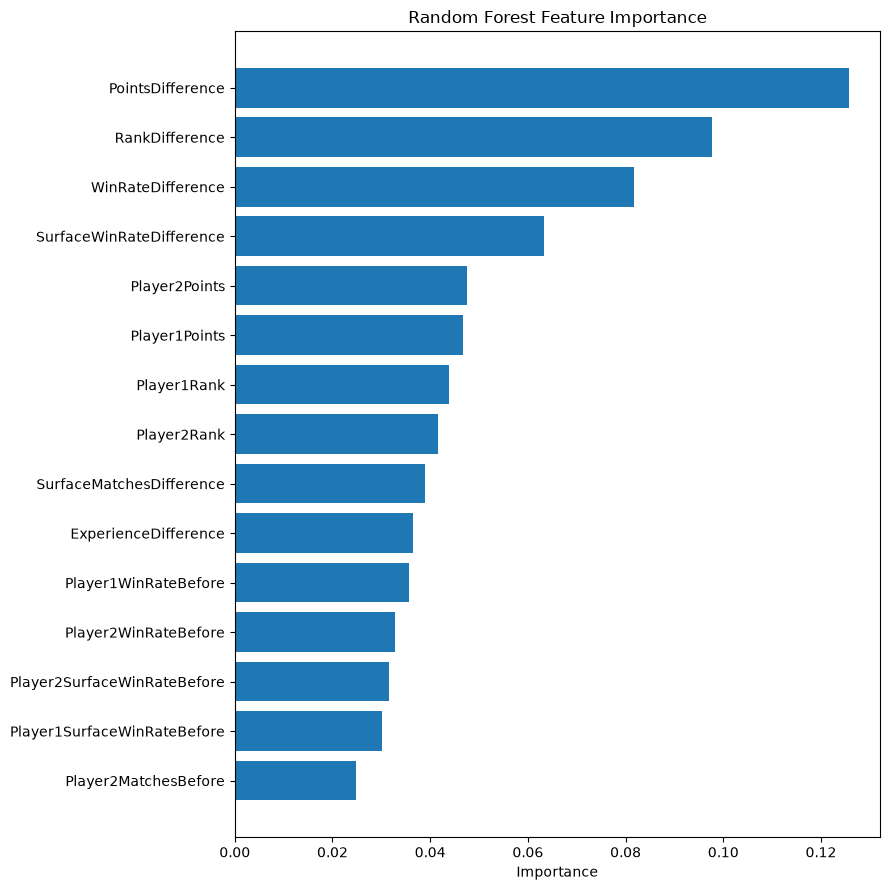

In [28]:
top_features = (
    feature_importance.head(15).sort_values(
        by="Importance", ascending=True
    )
)

plt.figure(figsize=(9, 9))
plt.barh(
    top_features["Feature"], 
    top_features["Importance"]
)
plt.title("Random Forest Feature Importance")
plt.xlabel("Importance")
plt.tight_layout()
plt.show()

### Feature importance

The feature importance values will be analysed after selecting
the best Random Forest configuration.

This analysis allows me to investigate whether the newly engineered
historical features and the categorical match information contribute
to the predictions.

In [29]:
RESULTS_DIR = Path("../results")
MODELS_DIR = Path("../models")

rf_cv_fold_results.to_csv(
    RESULTS_DIR / "rf_cv_fold_results.csv", index=False
)

rf_cv_summary.to_csv(
    RESULTS_DIR/ "RF_cv_tuning_summary.csv", index=False
)

feature_importance.to_csv(
    RESULTS_DIR / "RF_feature_importance.csv", index=False
)

best_rf_result.to_csv(
    RESULTS_DIR/ "best_rf_result.csv", index=False
)


In [30]:
import joblib 

joblib.dump(best_model, MODELS_DIR / "best_RF_validation.joblib")

['..\\models\\best_RF_validation.joblib']

In [31]:
# final tuning summary 
print( "Random Forest Temporal CV")

print(rf_cv_summary)

print(
    "\nSelected Random Forest:",
    best_model_name
)

print("\nExternal 2023 validation")
print(best_rf_result)

Random Forest Temporal CV
                    Model  MeanAccuracy  StdAccuracy  MeanBalancedAccuracy  \
0         RF 200 depth 10      0.641612     0.015238              0.641649   
1         RF 200 depth 15      0.639484     0.014980              0.639569   
2  RF 300 depth 10 leaf 2      0.639258     0.011782              0.639344   
3  RF 300 depth 15 leaf 2      0.638168     0.013094              0.638338   
4                  RF 100      0.629689     0.017209              0.629844   
5                  RF 200      0.627734     0.015754              0.627796   

   MeanF1Score  MeanROC_AUC  MeanLogLoss  
0     0.623721     0.702230     0.624893  
1     0.625950     0.694884     0.629909  
2     0.622160     0.703647     0.623535  
3     0.623833     0.697278     0.628350  
4     0.612559     0.682588     0.637232  
5     0.614992     0.685168     0.635369  

Selected Random Forest: RF 200 depth 10

External 2023 validation
             Model  Accuracy  BalancedAccuracy  Precision  

In [32]:
print("Top 15 features:")
print(feature_importance.head(15))

Top 15 features:
                        Feature  Importance
0              PointsDifference    0.125788
1                RankDifference    0.097723
2             WinRateDifference    0.081795
3      SurfaceWinRateDifference    0.063267
4                 Player2Points    0.047606
5                 Player1Points    0.046803
6                   Player1Rank    0.043834
7                   Player2Rank    0.041618
8      SurfaceMatchesDifference    0.038916
9          ExperienceDifference    0.036477
10         Player1WinRateBefore    0.035744
11         Player2WinRateBefore    0.032757
12  Player2SurfaceWinRateBefore    0.031553
13  Player1SurfaceWinRateBefore    0.030174
14         Player2MatchesBefore    0.024788
